In [4]:
# ONLY NEEDS TO BE RUN IF USING GOOGLE COLAB (remove this first line comment if so)
%%capture
!uv pip install s3fs zarr cftime fsspec rioxarray folium mapclassify

In [5]:
%%capture
!wget -O data_utils.py https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/main/Workshop_4/data_utils.py

*Workshop 4. Doing research with hydrological data*

# Practical: Rainfall in the Upper Severn

## Table of contents
<!-- 1. [Introduction](#0-introduction) -->
1. [Load rainfall data](#1-load-rainfall-data)
2. [Data formatting](#2-data-formatting)
3. [Compare gridded rainfall estimates and rain gauge data](#3-compare-gridded-rainfall-estimates-ceh-gear-and-rain-gauge-data)  
3.1. [Comparing one gauge to one grid cell](#31-comparing-one-gauge-to-one-grid-cell)  
3.2. [Scaling up our research workflow](#32-scaling-up-our-research-workflow)  
3.3. [Comparing catchment-mean rainfall](#33-comparing-catchment-mean-rainfall)  
4. [Saving research outputs](#4-saving-research-outputs)
5. [Additional tasks](#5-additional-tasks-)

## Learning objectives:
- Read in, format and analyse rainfall data from different sources
- Calculate and interpret basic statistics to compare rainfall estimates (gridded vs gauge)
- **Learn how to manage and scale up code for research**

# 0. Introduction
Rainfall is notoriously difficult to measure accurately, but in the UK we have a dense network of both [rain gauges](https://en.wikipedia.org/wiki/Rain_gauge) and [rain radar](https://en.wikipedia.org/wiki/Weather_radar) stations (**Figure 1**). These network gives us a relatively reliable and consistent estimate of rainfall through time, even when there is missing or wrong data, because estimates are cross-checked agaisnt other nearby measurements.

<p float="left">
    <img src="https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/main/Workshop_4/content/Maps-of-daily-rain-gauges-used-to-derive-the-CEH-GEAR-data-set-a-monthly-rain-gauges.png" alt="gauge-network" style="width:600px;"/>
</p>

*Figure 1. Maps of daily rain gauges in 2012: (a) monthly rain gauges and (b) daily rain gauges (source: Keller et al. 2015).*

## 0.1 Gridded rainfall data
Whilst, the UK's rain gauge network provides valuable data, its coverage is both spatially and temporally uneven. Some areas—such as Scotland—have a much denser concentration of gauges than others, like the South of England (see Figure 1). Additionally, the gauges themselves vary in age and data quality.  

As such, it can be inconvenient to work with rain gauge data. For this reason, environmental researchers often prefer datasets that are interpolated onto regular grids, which are easier to process, analyze, and compare over space and time.
> *Gridded rainfall products provide a spatially- and temporally-uniform estimate of rainfall*


For the UK, two main gridded rainfall products exist:  
1. CEH-GEAR — provides hourly & daily 1km gridded rainfall, produced by the [UKCEH](https://www.ceh.ac.uk/) and described in [Keller et al. 2015](https://essd.copernicus.org/articles/7/143/2015/)
2. HadUK-Grid — provides daily 1km gridded rainfall, produced by the [Met Office](https://www.metoffice.gov.uk/) and described in [Hollis et al. 2019](https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/gdj3.78)

In each case, the gridded rainfall estimates are built from different methodologies and using different underlying rain gauges, but both work by spatially interpolating data from the UK rain gauge network to a regular grid, a process shown diagramatically in Figure 2 (see more in those papers if you are interested in the specifics). For this practical, we will be using the CEH-GEAR dataset, but for future, you can access the HadUK-Grid [here](https://catalogue.ceda.ac.uk/uuid/4dc8450d889a491ebb20e724debe2dfb/)).

<p float="left">
    <img src="https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/main/Workshop_4/content/gridding_example_from_gdal.png" alt="gridding" style="width:600px;"/>
</p>

*Figure 2. Diagram showing example of interpolation of points to regular grid (source: GDAL 2025).*

## 0.2 Python libraries to read in rainfall data
In this practical, we will read in both 2-D gridded rainfall data and 1-D rain gauge data and compare them.  
To load data, we will use the following libraries...
- **Polars** a dataframe library (faster version of Pandas).
- **xarray** a library for reading in muli-dimensional arrays such as from NetCDF and TIF files.
- **Geopandas** a geospatial library for reading in spatial data formats like shapefiles.

<p float="left">
    <img src="https://raw.githubusercontent.com/Thomasjkeel/UKCEH_Summer_School/refs/heads/main/Workshop_4/content/polars_logo_icon_248809.png" alt="polars-logo" style="width:150px;"/>
    <img src="https://raw.githubusercontent.com/Thomasjkeel/UKCEH_Summer_School/refs/heads/main/Workshop_4/content/xarray-logo.png" alt="xarray-logo" style="width:150px;"/>
    <img src="https://raw.githubusercontent.com/Thomasjkeel/UKCEH_Summer_School/refs/heads/main/Workshop_4/content/geopandas-logo.png" alt="geopandas-logo" style="width:200px;"/>
</p>


## 0.3 Our study area
To keep the scope of this (or indeed any) research small, we will use a case study region: the sub-catchments of the upper part of the River Severn in Wales (see Figure 3). These sub-catcments are [topographically diverse](https://en-gb.topographic-map.com/map-cgt/United-Kingdom/?center=52.45936%2C-3.04871&zoom=8&popup=52.46864%2C-3.78574) and we have a limited amount of ground measurement sites (shown later in the practical). As such, we may need to rely on gridded rainfall estimate (like CEH-GEAR) to get a better picture of the rainfall patterns there.

<p float="left">
    <img src="https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/main/Workshop_4/content/upper_severn_study_area.png" alt="upper-severn-study-area" style="width:800px;"/>
</p>

*Figure 3. Our study area: sub-catchments in the Upper Severn.*


## 0.4 Final note about this practical
This practical sets out a small, but open-ended, research question: "How much does it rain in the Upper Severn?". But with this practical, we really want to introduce how you can lay out a notebook and set a foundation for answering research questions. A notebook that contains code that starts small, e.g. looking at a single gauge in a single location, and which expands and scales up naturally, e.g. to an entire catchment.

#### 🤨 Before we start (1 min)
Have a think, but what sort of ways could you approach the research question above? How could you start to answer this question? What sort of data would be needed? What sort of visualisations are useful? etc.

Let's begin by loading in the required Python libraries, and setting the geographic extent of our study area...

In [6]:
# Load required libraries
import fsspec
import zarr
import rioxarray

import geopandas as gpd
import polars as pl
import xarray as xr
import seaborn as sns

import matplotlib.pyplot as plt
import shapely.geometry

# practical-specific file:
import data_utils

In [7]:
# Global variables for coordinates of Upper Severn River catchment
SEVERN_NORTHING_RANGE = [270000, 349000]
SEVERN_EASTING_RANGE = [280000, 390000]

# 1. Load rainfall data
First we will read in gridded rainfall and rain gauge data using code similar to that shown in Workshop 2.

*External data sources:*
- **CEH-GEAR gridded rainfall data** - from the [JASMIN object-store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)
- **Rain gauge data for the Severn River Catchment** - from the [JASMIN object-store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)
- **Sub-catchment boundaries from the Severn** - from the National River Flow Archive ([NRFA](https://nrfa.ceh.ac.uk/data/search))
- **Watercourses from the River Severn region** - from [OS Open Rivers](https://www.ordnancesurvey.co.uk/products/os-open-rivers)

## 1.1 Load CEH-GEAR gridded rainfall data
Using the code from Workshop 2, below we connect to the S3 bucket on the JASMIN object-store (remote) and load in a local version of the daily CEH-GEAR file ("geardaily_fulloutput_yearly_100km_chunks.zarr")

In [8]:
fdri_fs = fsspec.filesystem(
    "s3", asynchronous=True, anon=True, endpoint_url="https://fdri-o.s3-ext.jc.rl.ac.uk"
)
gear_daily_zstore = zarr.storage.FsspecStore(
    fdri_fs, path="geardaily/GB/geardaily_fulloutput_yearly_100km_chunks.zarr"
)
gear_daily = xr.open_zarr(gear_daily_zstore, decode_times=True, decode_cf=True)
gear_daily  # 310 GB worth of data

<xarray.Dataset> Size: 666GB
Dimensions:          (time: 47481, y: 1251, x: 701)
Coordinates:
  * time             (time) datetime64[ns] 380kB 1890-01-01 ... 2019-12-31
  * y                (y) float64 10kB 1.25e+06 1.249e+06 1.248e+06 ... 1e+03 0.0
  * x                (x) float64 6kB 0.0 1e+03 2e+03 ... 6.98e+05 6.99e+05 7e+05
    lat              (y, x) float64 7MB dask.array<chunksize=(100, 100), meta=np.ndarray>
    lon              (y, x) float64 7MB dask.array<chunksize=(100, 100), meta=np.ndarray>
    crs              int16 2B ...
Data variables:
    min_dist         (time, y, x) float64 333GB dask.array<chunksize=(365, 100, 100), meta=np.ndarray>
    rainfall_amount  (time, y, x) float64 333GB dask.array<chunksize=(365, 100, 100), meta=np.ndarray>
Attributes: (12/21)
    Conventions:         CF-1.6
    comment:             In line with standard UK convention, the rainfall on...
    creator_email:       malngu@ceh.ac.uk, vke@ceh.ac.uk
    creator_name:        Maliko Tanguy, Virginie Keller
    creator_url:         
    date_issued:         2014-01-06
    ...                  ...
    publisher_email:     enquiries@ceh.ac.uk
    publisher_name:      Centre for Ecology and Hydrology
    publisher_url:       http://www.ceh.ac.uk
    reference:           Tanguy, M., Prosdocimi, I., Keller, V.D.J., Terry, J...
    source:              CEH - GEAR: dataset created using Natural Neighbour ...
    version_comment:     The version number of each data file corresponds to ...

Let's have a quick look at one day in the CEH-GEAR dataset...

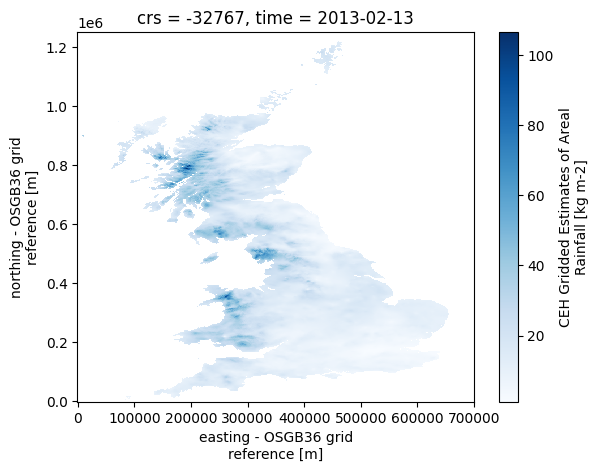

In [9]:
# plot data
# may take about 50 seconds
fig, ax = plt.subplots(1)
gear_daily.sel(time="2013-02-13")["rainfall_amount"].plot(ax=ax, cmap="Blues")

Remember, this figure shown daily rainfall for the entire UK from CEH-GEAR product. The CEH-GEAR spatially interpolates rain gauge observations to a regular 1km by 1km grid

## 1.2 Load daily rain gauge data
Next, we will load daily rain gauge data and it's associated metadata from the JASMIN object-store. Ignore the complicated way we are doing this, it is basically pointing to a CSV dataset which is stored in a cloud service.

🐻‍❄️ **Note:** we use the [polars](https://pola.rs/) instead of pandas to load data with `read_csv`.

In [10]:
severn_rain_gauge_data = pl.read_csv(
    "s3://rain-gauge/hourly_severn_rain_gauge_data.csv",
    storage_options={"endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk", "anon": True},
    try_parse_dates=True,
)
severn_rain_gauge_metadata = pl.read_csv(
    "s3://rain-gauge/hourly_severn_rain_gauge_metadata.csv",
    storage_options={"endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk", "anon": True},
)

In [11]:
severn_rain_gauge_data.head()

ID,DATETIME,PRECIPITATION
i64,datetime[μs],f64
89714,1978-10-01 00:00:00,0.0
89714,1978-10-02 00:00:00,2.0
89714,1978-10-03 00:00:00,0.0
89714,1978-10-04 00:00:00,0.0
89714,1978-10-05 00:00:00,0.0


In [12]:
severn_rain_gauge_metadata.head()

ID,SRC_ID,NAME,COUNTRY_CODE,EASTING,NORTHING,HYDROMETRIC_AREA,ELEVATION,GEOG_PATH
i64,i64,str,str,i64,i64,i64,i64,str
89714,2913,"""STRONGFORD W WKS""","""GB-GBN""",387932,339157,28,95,"""/BI/UK/GB/ENG/STS/"""
90358,2918,"""SUGNALL HALL""","""GB-GBN""",379831,331185,28,143,"""/BI/UK/GB/ENG/STS/"""
90359,2919,"""ECCLESHALL, SUGNALL HALL""","""GB-GBN""",379800,331200,28,137,"""/BI/UK/GB/ENG/STS/"""
90492,2920,"""WALTON HALL GARDENS""","""GB-GBN""",384900,328500,28,99,"""/BI/UK/GB/ENG/STS/"""
90537,2921,"""WHITMORE P STA""","""GB-GBN""",379900,340100,28,121,"""/BI/UK/GB/ENG/CHS/"""


Let's subset the data to look at precipitation from a single rain gauge...  

In [13]:
severn_rain_gauge_data.filter(pl.col("ID") == 90537)

ID,DATETIME,PRECIPITATION
i64,datetime[μs],f64
90537,1961-01-01 00:00:00,2.0
90537,1961-01-02 00:00:00,5.1
90537,1961-01-03 00:00:00,1.5
90537,1961-01-04 00:00:00,0.0
90537,1961-01-05 00:00:00,10.9
…,…,…
90537,1989-03-27 00:00:00,7.3
90537,1989-03-28 00:00:00,0.1
90537,1989-03-29 00:00:00,0.0


🐻‍❄️: to subset we use the dataframe's `.filter()` method, and we select the ID column with `pl.col("ID")`   
🐼: above code is equivalent to: `severn_rain_gauge_data.loc[severn_rain_gauge_data["ID"] == 90537]`

#### 🤨 Task: Subset the precipitation data to the station ID: 90492
Replace the ??? below with your answer

*Hint: you can use the `.filter` method like above*

In [14]:
severn_rain_gauge_data.filter(pl.col("ID") == 90492)

ID,DATETIME,PRECIPITATION
i64,datetime[μs],f64
90492,1973-02-01 00:00:00,0.5
90492,1973-02-02 00:00:00,0.5
90492,1973-02-03 00:00:00,0.0
90492,1973-02-04 00:00:00,0.0
90492,1973-02-05 00:00:00,0.2
…,…,…
90492,1988-04-26 00:00:00,4.6
90492,1988-04-27 00:00:00,1.1
90492,1988-04-28 00:00:00,0.0


#### 🤨 Optional task: Subset the precipitation data to the station: "WALFORD"

Replace the ??? below with your answer

In [15]:
# Step 1. Find the "ID" for the station with the name: "WALFORD" in the metadata
walford_id = severn_rain_gauge_metadata.filter(pl.col("NAME") == "WALFORD")['ID'][0]
print(walford_id)

429303


In [16]:
# Step 2. Using that ID, subset the rain gauge data
severn_rain_gauge_data.filter(pl.col("ID") == walford_id)

ID,DATETIME,PRECIPITATION
i64,datetime[μs],f64
429303,1973-09-01 00:00:00,0.5
429303,1973-09-02 00:00:00,19.0
429303,1973-09-03 00:00:00,0.5
429303,1973-09-04 00:00:00,0.0
429303,1973-09-05 00:00:00,0.0
…,…,…
429303,1983-12-27 00:00:00,0.0
429303,1983-12-28 00:00:00,0.0
429303,1983-12-29 00:00:00,0.0


## 1.3 Load spatial datasets for Upper Severn catchment
Finally, we download some spatial data for the River Severn, including catchment boundaries from the NRFA, and watercourse data from Ordinance Survey.

Data originally downloaded from: [NRFA](https://nrfa.ceh.ac.uk/data/search) & [Ordinance Survey](https://www.ordnancesurvey.co.uk/products/os-open-rivers)


This bash script below will fetch and download spatial data from GitHub and store it locally in the folder 'severn_catchment_data'

In [17]:
%%capture
!wget https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/main/Workshop_4/severn_catchment_data.tar.gz
!mkdir -p severn_catchment_data
!tar -xvf severn_catchment_data.tar.gz

Load shapefiles & geojson using geopandas

In [18]:
# Greater Severn catchment boundary
bewdley_shp = gpd.read_file("severn_catchment_data/Bewdley/54001/54001.shp")

# Upper Severn catchment boundaries
abermule_shp = gpd.read_file("severn_catchment_data/Abermule/54014/54014.shp")
dolwen_shp = gpd.read_file("severn_catchment_data/Dolwen/54080/54080.shp")
plynlimon_shp = gpd.read_file("severn_catchment_data/Plynlimon Flume/54022/54022.shp")

In [19]:
# Load rivers linestrings
severn_catchment_river_linestrings = gpd.read_file(
    "severn_catchment_data/rivers_around_severn.geojson"
)
severn_river_linestrings = severn_catchment_river_linestrings.loc[
    severn_catchment_river_linestrings["name1"].str.contains("River Severn")
]

Next, we plot the catchment boundaries and the River Severn

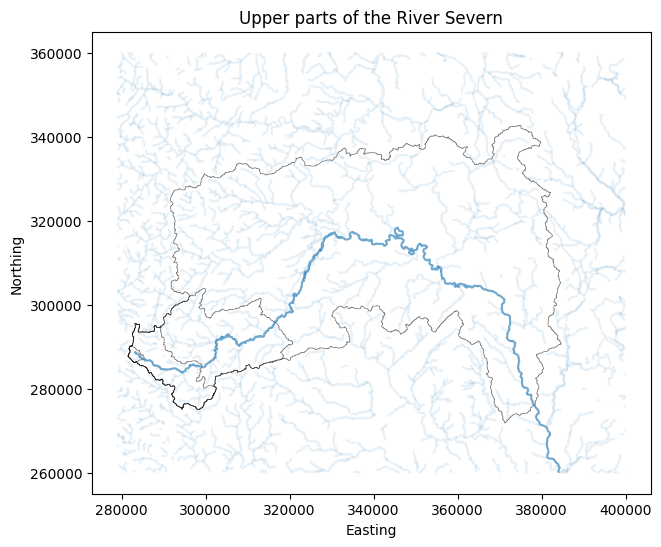

In [20]:
fig, ax = plt.subplots(1, figsize=(12, 6), sharex=True, sharey=True)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
abermule_shp.plot(ax=ax, facecolor="none", alpha=0.5, linewidth=0.5)
bewdley_shp.plot(ax=ax, facecolor="none", alpha=0.5, linewidth=0.5)
dolwen_shp.plot(ax=ax, facecolor="none", alpha=0.5, linewidth=0.5)
plynlimon_shp.plot(ax=ax, facecolor="none", alpha=0.5, linewidth=0.5)

severn_catchment_river_linestrings.plot(ax=ax, alpha=0.1)
severn_river_linestrings.plot(ax=ax, alpha=0.6)
ax.set_title("Upper parts of the River Severn")
plt.subplots_adjust(hspace=0.2)

#### 🤨 Question: What do the outlines/borders on this plot represent?
Answer: catchment boundaries

Next we'll also load in some topographic height data (in m) and plot that

In [21]:
severn_hght = rioxarray.open_rasterio("severn_catchment_data/HGHT_SEVERN_1KM_CLIP.tif")
severn_hght = severn_hght.sortby("y")
severn_hght = severn_hght.sel(band=1)
severn_hght = severn_hght * 10  # multiply by 10, so in metres
severn_hght = severn_hght.sel(
    x=slice(*SEVERN_EASTING_RANGE), y=slice(*SEVERN_NORTHING_RANGE)
)

Text(0.5, 1.0, 'Height profile of upper parts of the River Severn')

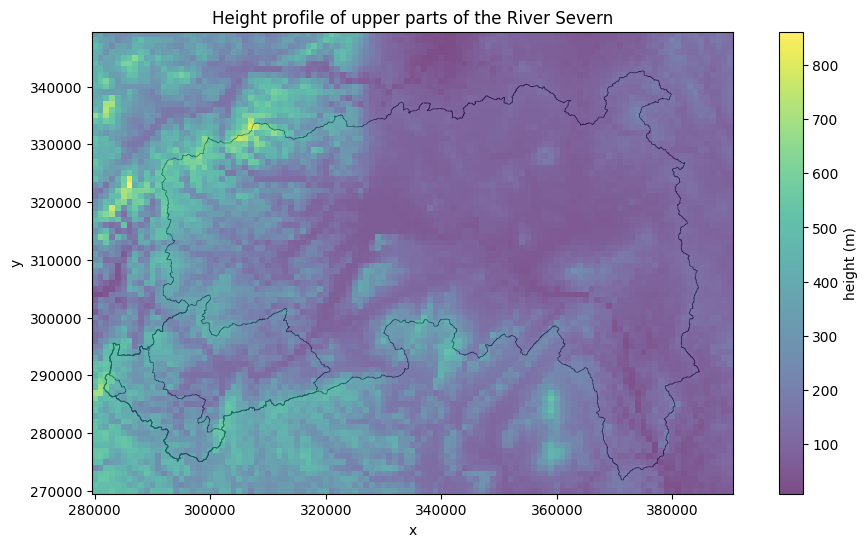

In [22]:
fig, ax = plt.subplots(1, figsize=(12, 6), sharex=True, sharey=True)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
abermule_shp.plot(ax=ax, facecolor="none", linewidth=0.5)
bewdley_shp.plot(ax=ax, facecolor="none", linewidth=0.5)
dolwen_shp.plot(ax=ax, facecolor="none", linewidth=0.5)
plynlimon_shp.plot(ax=ax, facecolor="none", linewidth=0.5)
severn_hght.plot(ax=ax, alpha=0.7, cbar_kwargs={"label": "height (m)"})

ax.set_title("Height profile of upper parts of the River Severn")

# 2. Data Formatting
Most of data science is about data cleaning and formatting.  
^^^This is especially true for those using environmental data, where we often have datasets from many different sources, and that are of varying quality.

In this section, we will prepare the datasets, so we can compare the rain gauge dataset to gridded rainfall in the next section.


## 2.1 Checking for gaps in rain observation data
There are many issues with the rain gauge observation dataset we are using because it has not been quality controlled. This includes gaps, streaks of repeating values, exceedances of world records, misinputted data, etc.. However, in the interest of moving swiftly on, we will only focus on finding gaps in this practical. To do this we calculate a data 'completeness' for each gauge comparing number of rows to expected number of rows.

<p float="left">
    <img src="https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/update/workshop-4/Workshop_4/content/example_of_daily_rain_gauge_record.png" alt="daily-rain-gauges" style="width:600px;"/>
</p>

*Figure 4. Example rainfall record from a daily rain gauge.*

>*Note:* if you are interested in quality controlling rain gauge data, see the Python package [RainfallQC](https://github.com/NERC-CEH/RainfallQC) and find some examples [here](https://nerc-ceh.github.io/RainfallQC/)


In [23]:
# To save RAM later on, we'll filter out rows before 1990
severn_rain_gauge_data = severn_rain_gauge_data.filter(
    pl.col("DATETIME") > pl.date(year=1990, month=1, day=1)
)

In [24]:
# load in a single gappy gauge (ID=90806)
one_gauge = severn_rain_gauge_data.filter(pl.col("ID") == 90806)

<Axes: xlabel='DATETIME'>

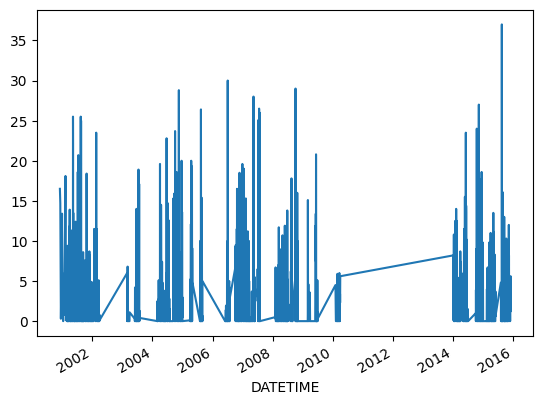

In [25]:
# plot data to see gaps
one_gauge.to_pandas().set_index("DATETIME")[
    "PRECIPITATION"
].plot()  # here we convert polars to pandas to let us plot longer time series

In the above plot, clearly there are some gaps in the data. We do not want to include this in our final clean dataset.  

Let's create a completeness metric, by comparing the start and end dates of each gauge, and then checking how many data rows are missing

In [26]:
# Compute observed number of days between start and end date (i.e. this is the number of observations in the data)
severn_rain_gauge_data_observed = severn_rain_gauge_data.group_by("ID").agg(
    [
        pl.col("DATETIME").min().alias("start_date"),
        pl.col("DATETIME").max().alias("end_date"),
        pl.len().alias("observed_days"),
    ]
)
severn_rain_gauge_data_observed.head()

ID,start_date,end_date,observed_days
i64,datetime[μs],datetime[μs],u32
90805,2007-03-01 00:00:00,2024-12-31 00:00:00,6485
423008,1990-01-02 00:00:00,2005-02-28 00:00:00,5262
426762,1990-01-02 00:00:00,2001-02-28 00:00:00,4076
427444,1990-01-02 00:00:00,2024-12-31 00:00:00,12143
91773,1990-02-01 00:00:00,1991-07-31 00:00:00,515


In [27]:
# Compute expected number of days between start and end date
severn_rain_gauge_data_observed_and_expected = (
    severn_rain_gauge_data_observed.with_columns(
        [
            ((pl.col("end_date") - pl.col("start_date")).dt.total_days() + 1).alias(
                "expected_days"
            ),
        ]
    )
)

severn_rain_gauge_data_observed_and_expected.head()

ID,start_date,end_date,observed_days,expected_days
i64,datetime[μs],datetime[μs],u32,i64
90805,2007-03-01 00:00:00,2024-12-31 00:00:00,6485,6516
423008,1990-01-02 00:00:00,2005-02-28 00:00:00,5262,5537
426762,1990-01-02 00:00:00,2001-02-28 00:00:00,4076,4076
427444,1990-01-02 00:00:00,2024-12-31 00:00:00,12143,12783
91773,1990-02-01 00:00:00,1991-07-31 00:00:00,515,546


In [28]:
# Divide observed by expected and get percentage completeness
severn_rain_gauge_data_completeness = (
    severn_rain_gauge_data_observed_and_expected.with_columns(
        [
            ((pl.col("observed_days") / pl.col("expected_days")) * 100).alias(
                "perc_completeness"
            )
        ]
    )
)

severn_rain_gauge_data_completeness.head()

ID,start_date,end_date,observed_days,expected_days,perc_completeness
i64,datetime[μs],datetime[μs],u32,i64,f64
90805,2007-03-01 00:00:00,2024-12-31 00:00:00,6485,6516,99.524248
423008,1990-01-02 00:00:00,2005-02-28 00:00:00,5262,5537,95.033412
426762,1990-01-02 00:00:00,2001-02-28 00:00:00,4076,4076,100.0
427444,1990-01-02 00:00:00,2024-12-31 00:00:00,12143,12783,94.993351
91773,1990-02-01 00:00:00,1991-07-31 00:00:00,515,546,94.322344


Some of the rain gauges are particularly gappy...  
Remember 60 % completeness, means that only 60% of the days between the start and end date actually have a record for rainfall (maybe someone forgot on the other days)

In [29]:
severn_rain_gauge_data_completeness.filter(pl.col("perc_completeness") < 60)

ID,start_date,end_date,observed_days,expected_days,perc_completeness
i64,datetime[μs],datetime[μs],u32,i64,f64
90806,2000-12-05 00:00:00,2015-11-30 00:00:00,1989,5474,36.335404
429827,1995-01-01 00:00:00,1996-05-31 00:00:00,212,517,41.005803


Always a good idea to use a histogram to view the distribution of your data too...

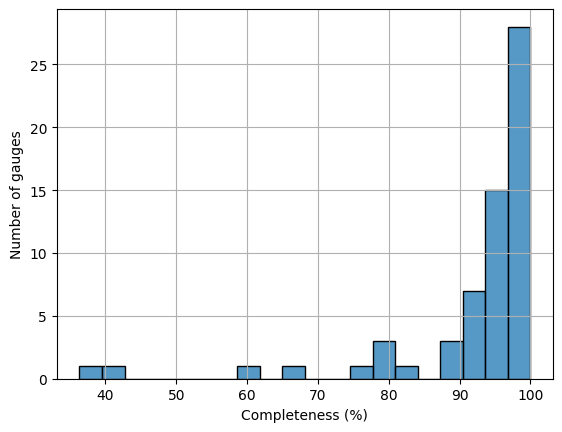

In [30]:
fig, ax = plt.subplots(1)
sns.histplot(severn_rain_gauge_data_completeness["perc_completeness"], ax=ax)
ax.set_ylabel("Number of gauges")
ax.set_xlabel("Completeness (%)")
ax.grid()

Hmm, there are only a few gauges with very gappy data, let's remove everything below 90% just to be safe

### ⭐ 🤨 Essential Task: Filter out data with less than 90% completeness
Let's create a dataset that is more reliable

Replace the ??? below with your answer

*Hint: remember to break down the problem into steps, and print things out in a new code block if unsure*

In [31]:
# Step 1. Get the IDs of gauges above 90% threshold
reliable_gauge_ids = severn_rain_gauge_data_completeness.filter(
    pl.col("perc_completeness") > 90
)["ID"].to_list()

In [32]:
# filter data to include only those ID's with more than 90% completeness
severn_rain_gauge_data_filtered = severn_rain_gauge_data.filter(
    pl.col("ID").is_in(reliable_gauge_ids)
)

In [33]:
severn_rain_gauge_data_filtered

ID,DATETIME,PRECIPITATION
i64,datetime[μs],f64
90358,1990-01-02 00:00:00,4.4
90358,1990-01-03 00:00:00,0.0
90358,1990-01-04 00:00:00,0.0
90358,1990-01-05 00:00:00,1.0
90358,1990-01-06 00:00:00,7.3
…,…,…
429745,2024-12-27 00:00:00,0.4
429745,2024-12-28 00:00:00,0.2
429745,2024-12-29 00:00:00,0.0


#### 🤨 Optional task: Take a closer look at the gauge 428554 (by plotting), what other issues can you see that will need to be quality controlled?:


In [34]:
severn_rain_gauge_data_filtered.filter(pl.col("ID") == 428554).to_pandas()

,ID,DATETIME,PRECIPITATION


# 2.2 Subset spatial data

The gridded data from CEH-GEAR daily (stored in the variable: `gear_daily`) provides rainfall estimates which cover the entire UK region, but in our case study we only want to look at a small sub-catchment (the Upper Severn). Let's subset our data into the areas around the River Severn only and for data since 1990 (to make this notebook run quicker).

*Hint: always subset your data when testing workflows*

In [35]:
# subset CEH-GEAR to SEVERN CATCHMENT
severn_gear_daily = gear_daily.sel(
    x=slice(*SEVERN_EASTING_RANGE),
    y=slice(
        *sorted(SEVERN_NORTHING_RANGE, reverse=True)
    ),  # has to be reversed as y coordinates is descending
    time=slice("1990", None),
)
severn_gear_daily = severn_gear_daily.drop_vars("min_dist")  # drop unecessary variable
severn_gear_daily = severn_gear_daily.sortby("y")  # flip y coordinates

In [36]:
%%time
# Load data into RAM (memory)
# this code-block takes about 45 seconds
severn_gear_daily.load()

CPU times: user 4.04 s, sys: 850 ms, total: 4.89 s
Wall time: 3min 42s


<xarray.Dataset> Size: 779MB
Dimensions:          (time: 10957, y: 80, x: 111)
Coordinates:
  * time             (time) datetime64[ns] 88kB 1990-01-01 ... 2019-12-31
  * y                (y) float64 640B 2.7e+05 2.71e+05 ... 3.48e+05 3.49e+05
  * x                (x) float64 888B 2.8e+05 2.81e+05 ... 3.89e+05 3.9e+05
    lat              (y, x) float64 71kB 9.969e+36 9.969e+36 ... 9.969e+36
    lon              (y, x) float64 71kB 9.969e+36 9.969e+36 ... 9.969e+36
    crs              int16 2B -32767
Data variables:
    rainfall_amount  (time, y, x) float64 778MB 10.5 10.5 10.6 ... 0.0 0.0 0.0
Attributes: (12/21)
    Conventions:         CF-1.6
    comment:             In line with standard UK convention, the rainfall on...
    creator_email:       malngu@ceh.ac.uk, vke@ceh.ac.uk
    creator_name:        Maliko Tanguy, Virginie Keller
    creator_url:         
    date_issued:         2014-01-06
    ...                  ...
    publisher_email:     enquiries@ceh.ac.uk
    publisher_name:      Centre for Ecology and Hydrology
    publisher_url:       http://www.ceh.ac.uk
    reference:           Tanguy, M., Prosdocimi, I., Keller, V.D.J., Terry, J...
    source:              CEH - GEAR: dataset created using Natural Neighbour ...
    version_comment:     The version number of each data file corresponds to ...

You can also see the spatial distribution of the rain gauge data in the below plot. There are gaps in gauge network towards the east of study area, but we will ignore these in this practical.

Text(0.5, 1.0, 'Distribution of rain gauges in Upper Severn')

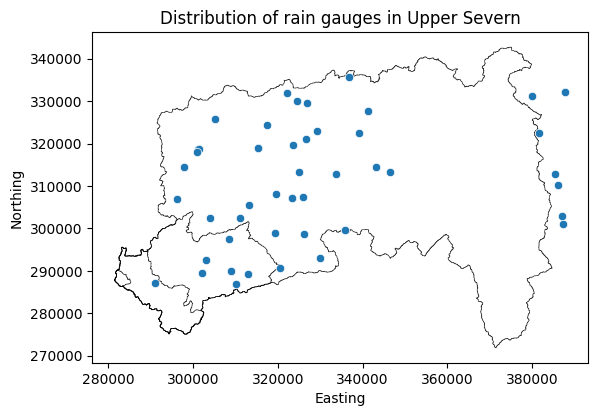

In [37]:
fig, ax = plt.subplots(1)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
abermule_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
bewdley_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
dolwen_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
plynlimon_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
sns.scatterplot(
    x="EASTING",
    y="NORTHING",
    data=severn_rain_gauge_metadata.filter(pl.col("ID").is_in(reliable_gauge_ids)),
)
ax.set_title("Distribution of rain gauges in Upper Severn")

# 3. Compare gridded rainfall estimates (CEH-GEAR) and rain gauge data
Okay, now we can start running some analysis. Let's calculate some simple statistics of difference between gridded rainfall estimates and rain gauge observations.


## 3.1. Comparing one gauge to one grid cell
First, let's look at how we can join a single rain gauge to its nearest grid cell in the CEH-GEAR.  
We are selecting only one gauge (ID=428553, name="PRESTON MONTFORD")  at first to see how our workflow will work before scaling this up to look at entire catchment of gauges

<p float="left">
    <img src="https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/update/workshop-4/Workshop_4/content/preston_montford_highlight.png" alt="preston-montford" style="width:500px;"/>
</p>

*Figure 5. Location of the Preston Montford rain gauge in the Upper Severn.*


In [38]:
CHOSEN_GAUGE_ID = 428553 # should be the Preston Montford rain gauge

In [39]:
# filter the metadata for Preston Montford
one_gauge = severn_rain_gauge_data_filtered.filter(pl.col("ID") == CHOSEN_GAUGE_ID)
one_gauge_metadata = severn_rain_gauge_metadata.filter(pl.col("ID") == CHOSEN_GAUGE_ID)
one_gauge_completeness = severn_rain_gauge_data_completeness.filter(
    pl.col("ID") == CHOSEN_GAUGE_ID
)

In [40]:
one_gauge

ID,DATETIME,PRECIPITATION
i64,datetime[μs],f64
428553,1990-01-02 00:00:00,4.4
428553,1990-01-03 00:00:00,0.0
428553,1990-01-04 00:00:00,0.0
428553,1990-01-05 00:00:00,0.4
428553,1990-01-06 00:00:00,2.2
…,…,…
428553,2024-12-27 00:00:00,0.5
428553,2024-12-28 00:00:00,0.1
428553,2024-12-29 00:00:00,0.0


In [41]:
one_gauge_metadata  # ah, PRESTON MONTFORD is at an elevation of 71 meters

ID,SRC_ID,NAME,COUNTRY_CODE,EASTING,NORTHING,HYDROMETRIC_AREA,ELEVATION,GEOG_PATH
i64,i64,str,str,i64,i64,i64,i64,str
428553,638,"""PRESTON MONTFORD""","""GB-GBN""",343246,314441,54,71,"""/BI/UK/GB/ENG/SAL/"""


We can use the `method='nearest'` argument to get the nearest grid cell to our gauge's coordinates

In [42]:
# spatial subset (get nearest grid cell)
one_gauge_grid_cell = severn_gear_daily.sel(
    x=one_gauge_metadata["EASTING"], y=one_gauge_metadata["NORTHING"], method="nearest"
)

# time subset (get data that overlaps in time)
one_gauge_grid_cell = one_gauge_grid_cell.sel(
    time=slice(
        one_gauge_completeness["start_date"].item(),
        one_gauge_completeness["end_date"].item(),
    )
)

In [43]:
one_gauge_grid_cell

<xarray.Dataset> Size: 175kB
Dimensions:          (time: 10956, y: 1, x: 1)
Coordinates:
  * time             (time) datetime64[ns] 88kB 1990-01-02 ... 2019-12-31
  * y                (y) float64 8B 3.14e+05
  * x                (x) float64 8B 3.43e+05
    lat              (y, x) float64 8B 9.969e+36
    lon              (y, x) float64 8B 9.969e+36
    crs              int16 2B -32767
Data variables:
    rainfall_amount  (time, y, x) float64 88kB 4.304 0.0 0.0 ... 0.0 0.0 0.0
Attributes: (12/21)
    Conventions:         CF-1.6
    comment:             In line with standard UK convention, the rainfall on...
    creator_email:       malngu@ceh.ac.uk, vke@ceh.ac.uk
    creator_name:        Maliko Tanguy, Virginie Keller
    creator_url:         
    date_issued:         2014-01-06
    ...                  ...
    publisher_email:     enquiries@ceh.ac.uk
    publisher_name:      Centre for Ecology and Hydrology
    publisher_url:       http://www.ceh.ac.uk
    reference:           Tanguy, M., Prosdocimi, I., Keller, V.D.J., Terry, J...
    source:              CEH - GEAR: dataset created using Natural Neighbour ...
    version_comment:     The version number of each data file corresponds to ...

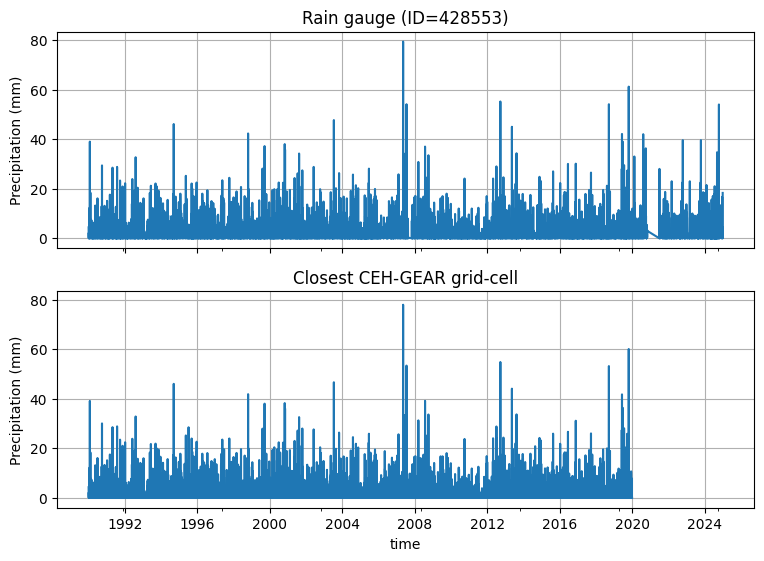

In [44]:
# plot both time series on the same y-axis
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, sharey=True)

one_gauge.to_pandas().set_index("DATETIME")["PRECIPITATION"].plot(ax=axes[0])
one_gauge_grid_cell["rainfall_amount"].plot(ax=axes[1])

axes[0].set_title(f"Rain gauge (ID={CHOSEN_GAUGE_ID})")
axes[1].set_title("Closest CEH-GEAR grid-cell")

for ax in axes:
    ax.grid()
    ax.set_ylabel("Precipitation (mm)")

They look a bit similar, but is hard to tell because this is a daily record.  
Let's more directly compare the two...

In [45]:
# extract data from the nearest grid cell
one_gauge_grid_cell_df = pl.DataFrame(
    {
        "DATETIME": one_gauge_grid_cell["time"].data.flatten(),
        "PRECIPITATION_GRID": one_gauge_grid_cell["rainfall_amount"].data.flatten(),
    }
)

# This is needed to get datetime in correct format
one_gauge_grid_cell_df = one_gauge_grid_cell_df.with_columns(
    pl.col("DATETIME").cast(pl.Datetime("us"))
)

In [46]:
# Join the data together
one_gauge_joined = one_gauge.join(one_gauge_grid_cell_df, on="DATETIME", how="left")
one_gauge_joined = one_gauge_joined.rename({"PRECIPITATION": "PRECIPITATION_GAUGE"})
one_gauge_joined.head()

ID,DATETIME,PRECIPITATION_GAUGE,PRECIPITATION_GRID
i64,datetime[μs],f64,f64
428553,1990-01-02 00:00:00,4.4,4.303909
428553,1990-01-03 00:00:00,0.0,0.0
428553,1990-01-04 00:00:00,0.0,0.0
428553,1990-01-05 00:00:00,0.4,0.400364
428553,1990-01-06 00:00:00,2.2,2.202


##### ❓ Question: The two rainfall records seem similar, but are they correlated?
*Hint: see cell below*  
**Answer:** ???

In [47]:
# Run a pearson Correlation
one_gauge_joined.select(
    pl.corr("PRECIPITATION_GAUGE", "PRECIPITATION_GRID", method="pearson")
)

PRECIPITATION_GAUGE
f64
0.998178


Let's compute a difference through time

In [48]:
one_gauge_joined = one_gauge_joined.with_columns(
    (pl.col("PRECIPITATION_GAUGE") - pl.col("PRECIPITATION_GRID")).alias(
        "rainfall_diff"
    )
)

In [49]:
one_gauge_joined.head()

ID,DATETIME,PRECIPITATION_GAUGE,PRECIPITATION_GRID,rainfall_diff
i64,datetime[μs],f64,f64,f64
428553,1990-01-02 00:00:00,4.4,4.303909,0.096091
428553,1990-01-03 00:00:00,0.0,0.0,0.0
428553,1990-01-04 00:00:00,0.0,0.0,0.0
428553,1990-01-05 00:00:00,0.4,0.400364,-0.000364
428553,1990-01-06 00:00:00,2.2,2.202,-0.002


In [50]:
# drop null values so that we are not including values where either the CEH-GEAR or rain gauge is a missing value
one_gauge_joined = one_gauge_joined.drop_nulls()

Text(0, 0.5, 'Rainfall difference (mm)')

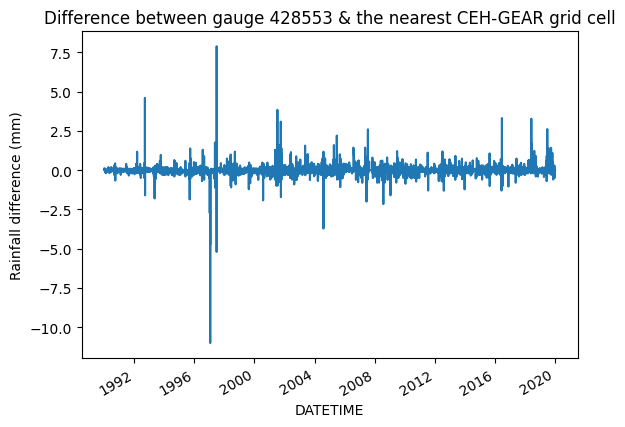

In [51]:
one_gauge_joined.to_pandas().set_index("DATETIME")["rainfall_diff"].plot()
plt.title(
    f"Difference between gauge {CHOSEN_GAUGE_ID} & the nearest CEH-GEAR grid cell"
)
plt.ylabel("Rainfall difference (mm)")

In [52]:
print("mean difference =", one_gauge_joined["rainfall_diff"].mean())

mean difference = -0.0014909385934183375


Looks like the variability of the rainfall difference might change through after around 2009, let's look quickly look at the standard deviation before and after 2009

In [53]:
rainfall_difference_before2000 = one_gauge_joined.filter(pl.col("DATETIME") < pl.date(year=2009, month=1, day=1))['rainfall_diff']
rainfall_difference_after2009 = one_gauge_joined.filter(pl.col("DATETIME") >= pl.date(year=2009, month=1, day=1))['rainfall_diff']

In [54]:
print(f"Standard deviation of difference 1990-2009: {rainfall_difference_before2000.std()}")
print(f"Standard deviation in difference 2009-2019: {rainfall_difference_after2009.std()}")

Standard deviation of difference 1990-2009: 0.27926313103752737
Standard deviation in difference 2009-2019: 0.17562683055342676


It also looks like there may be an decrease in the number of days where the estimate difference is above -/+ 1 mm
#### 🤨 Optional Task: Use the `filter` method to get the number of days where the rainfall difference is -/+ 1 and then count the number of days each year

Replace the ??? below with your answer

*Hint: because you are looking for +/- 1, it is a good idea to use absolute numbers i.e. abs()*  
*Hint: group_by_dynamic*

In [55]:
num_days_each_year_w_large_diff = one_gauge_joined.filter(abs(pl.col("rainfall_diff")) > 1).group_by_dynamic("DATETIME", every="1y").agg(pl.col("rainfall_diff").count())
num_days_each_year_w_large_diff

DATETIME,rainfall_diff
datetime[μs],u32
1992-01-01 00:00:00,3
1993-01-01 00:00:00,1
1995-01-01 00:00:00,2
1996-01-01 00:00:00,1
1997-01-01 00:00:00,11
…,…
2013-01-01 00:00:00,1
2015-01-01 00:00:00,2
2016-01-01 00:00:00,4


## 3.1.1 Look at monthly running total
To make the plot more visually appealing, we can compute the difference in rainfall based on monthly sum. this wasy, we will get less spikes

In [56]:
# group data into monthly sum
one_gauge_monthly_sums = one_gauge_joined.group_by_dynamic("DATETIME", every="1mo").agg(
    [pl.col("PRECIPITATION_GAUGE").sum(), pl.col("PRECIPITATION_GRID").sum()]
)

In [57]:
one_gauge_monthly_sums = one_gauge_monthly_sums.with_columns(
    (pl.col("PRECIPITATION_GAUGE") - pl.col("PRECIPITATION_GRID")).alias(
        "rainfall_diff"
    )
)

In [58]:
one_gauge_monthly_sums.head()

DATETIME,PRECIPITATION_GAUGE,PRECIPITATION_GRID,rainfall_diff
datetime[μs],f64,f64,f64
1990-01-01 00:00:00,102.8,102.993545,-0.193545
1990-02-01 00:00:00,82.1,82.8,-0.7
1990-03-01 00:00:00,11.1,11.2,-0.1
1990-04-01 00:00:00,24.3,24.1,0.2
1990-05-01 00:00:00,29.2,29.0,0.2


#### 🤨 Task: What is the mean monthly difference?
Replace the ??? below with your answer

In [59]:
one_gauge_monthly_sums["rainfall_diff"].mean()

-0.04479573575579235

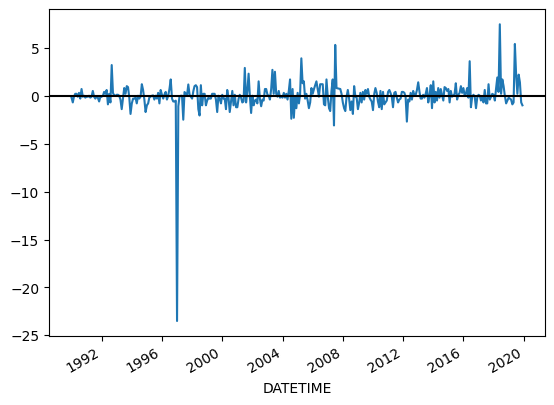

In [60]:
one_gauge_monthly_sums.to_pandas().set_index("DATETIME")["rainfall_diff"].plot()
plt.axhline(color="k")

Hmm, is there any sort of trend in this data? Is it related to the number of gauges in the Upper Severn? That's a research question for another time...

##### ❓ Question for now: Is the nearest CEH-GEAR grid cell over or underestimating rainfall relative to the rain gauge?

Answer: ???

#### 🤨 Task: Change the resolution of the time group_by below to:
1. 6 months
2. 1 year
3. Resolution of your chosing

Replace the ??? below with your answer

*Hint: find out online the correct syntax to group every 6 months and 1 year*
   

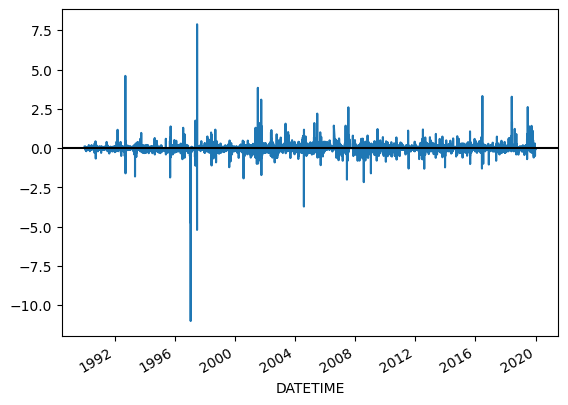

In [61]:
one_gauge_joined_6m = one_gauge_joined.group_by_dynamic("DATETIME", every="6m").agg(
    [
    pl.col("PRECIPITATION_GAUGE").sum(),
    pl.col("PRECIPITATION_GRID").sum()
    ]
)

m6_rainfall_diff = one_gauge_joined_6m.with_columns(
    (pl.col("PRECIPITATION_GAUGE") - pl.col("PRECIPITATION_GRID")).alias("rainfall_diff")
)

m6_rainfall_diff.to_pandas().set_index("DATETIME")['rainfall_diff'].plot()
plt.axhline(color='k')

#### 🤨 Optional task: Before moving on, go back to 3.1 and replace CHOSEN_GAUGE_ID with a new ID, then re-run all cells in 3.1

## 3.2 Scaling up our research workflow
A lot of data research involves trial and error and repetition. It is always a good idea to get something working with a small subset before scaling up and applying your analysis to an entire dataset. In our case, we have code to compute a simple difference between a rain gauge and its nearest CEH-GEAR grid cell. Now let's scale that up to look at all gauges in a catchment...

> In this section, we bring everything together, and scale up our research code   

Below are some functions with relatively descriptive names that will carry out all the analysis we saw in section 3.1.
In writing these, we have tried to stick to the Single Responsibility Principle as best we can (that is, one function does one thing)

In [62]:
def calc_mean_diff_between_rain_gauge_and_nearest_grid_cell(
                                                            gauge_id,
                                                            rain_gauge_data=severn_rain_gauge_data_filtered,
                                                            rain_gauge_metadata=severn_rain_gauge_metadata,
                                                            rain_gauge_data_w_completeness=severn_rain_gauge_data_completeness,
                                                            gear_data=severn_gear_daily
                                                            ):
    """
    Calculate mean difference between a given rain gauge and the nearest CEH-GEAR grid cell.

    Values for rain_gauge_data and metadata are hard-coded for now, but please edit if you use elsewhere.
    """
    if not gauge_id in rain_gauge_data['ID'].unique().to_list():
        raise ValueError(f"Gauge ID {gauge_id} not in data")
    # 1. Load in gauge data and related metadata
    one_gauge = rain_gauge_data.filter(pl.col("ID") == gauge_id)
    one_gauge_metadata = rain_gauge_metadata.filter(pl.col("ID") == gauge_id)
    one_gauge_completeness = rain_gauge_data_w_completeness.filter(
        pl.col("ID") == gauge_id
    )

    # 2. Get nearest CEH-GEAR grid cell
    one_gauge_grid_cell = get_nearest_gear_data_by_coords(
        gear_data=gear_data,
        easting=one_gauge_metadata["EASTING"],
        northing=one_gauge_metadata["NORTHING"]
    )

    # 3. Subset nearest grid cell data by start end date of gauge
    one_gauge_grid_cell = subset_gear_data_by_gauge_start_end_date(
        gear_data=one_gauge_grid_cell,
        start_date=one_gauge_completeness["start_date"].item(),
        end_date=one_gauge_completeness["end_date"].item(),
    )

    # 4. Convert data into polars format
    one_gauge_grid_cell_df = convert_gear_data_to_polars_df(one_gauge_grid_cell)

    # 5. Join to rain gauge data
    one_gauge_joined = one_gauge.join(one_gauge_grid_cell_df, on="DATETIME", how="left")
    one_gauge_joined = one_gauge_joined.rename({"PRECIPITATION": "PRECIPITATION_GAUGE"})

    # 6. Calculate daily rainfall differences
    one_gauge_joined = calculate_rainfall_difference(one_gauge_joined)
    return one_gauge_joined


def get_nearest_gear_data_by_coords(gear_data, easting, northing):
    """
    Get nearest CEH-GEAR data by easting and northing coords
    """
    return gear_data.sel(x=easting, y=northing, method="nearest")


def subset_gear_data_by_gauge_start_end_date(gear_data, start_date, end_date):
    return gear_data.sel(time=slice(start_date, end_date))


def convert_gear_data_to_polars_df(gear_data):
    gear_data_rainfall_amount = gear_data["rainfall_amount"].data.flatten()
    gear_data_time = gear_data["time"].data.flatten()

    gear_data_df = pl.DataFrame(
        {"DATETIME": gear_data_time, "PRECIPITATION_GRID": gear_data_rainfall_amount}
    )
    gear_data_df = gear_data_df.with_columns(pl.col("DATETIME").cast(pl.Datetime("us")))
    return gear_data_df


def calculate_rainfall_difference(one_gauge_joined):
    one_gauge_joined = one_gauge_joined.with_columns(
        (pl.col("PRECIPITATION_GAUGE") - pl.col("PRECIPITATION_GRID")).alias(
            "rainfall_diff"
        )
    )
    one_gauge_joined = one_gauge_joined.drop_nulls()
    return one_gauge_joined

In [63]:
CHOSEN_GAUGE_ID = 90358

In [64]:
calc_mean_diff_between_rain_gauge_and_nearest_grid_cell(gauge_id=CHOSEN_GAUGE_ID)

ID,DATETIME,PRECIPITATION_GAUGE,PRECIPITATION_GRID,rainfall_diff
i64,datetime[μs],f64,f64,f64
90358,1990-01-02 00:00:00,4.4,4.391296,0.008704
90358,1990-01-03 00:00:00,0.0,0.0,0.0
90358,1990-01-04 00:00:00,0.0,0.0,0.0
90358,1990-01-05 00:00:00,1.0,0.998022,0.001978
90358,1990-01-06 00:00:00,7.3,7.285559,0.014441
…,…,…,…,…
90358,2019-12-27 00:00:00,0.0,0.0,0.0
90358,2019-12-28 00:00:00,0.0,0.0,0.0
90358,2019-12-29 00:00:00,0.0,0.0,0.0


Now, we have an easy one line to compute rainfall difference, we can loop through each gauge and compute some overall statistics

In [65]:
# get all ids
all_unique_gauge_ids = severn_rain_gauge_data_filtered["ID"].unique().to_list()
print(len(all_unique_gauge_ids))
all_unique_gauge_ids[:5] + ["..."]

50


[90358, 90803, 90805, 91177, 91196, '...']

In [66]:
%%time
# Store all statistics in a dictionary
all_gauge_comparisons = []

for gauge_id in all_unique_gauge_ids:
    gauge_comparison = {}
    one_gauge_rainfall_diff = calc_mean_diff_between_rain_gauge_and_nearest_grid_cell(
        gauge_id=gauge_id
    )
    gauge_comparison["gauge_id"] = gauge_id
    gauge_comparison["stdev_diff"] = one_gauge_rainfall_diff["rainfall_diff"].mean()
    gauge_comparison["mean_diff"] = one_gauge_rainfall_diff["rainfall_diff"].std()
    gauge_comparison["max_diff"] = one_gauge_rainfall_diff["rainfall_diff"].max()
    gauge_comparison["min_diff"] = one_gauge_rainfall_diff["rainfall_diff"].min()
    all_gauge_comparisons.append(gauge_comparison)

CPU times: user 321 ms, sys: 31.6 ms, total: 353 ms
Wall time: 324 ms


In [67]:
all_gauge_comparisons_df = pl.from_dicts(all_gauge_comparisons)
all_gauge_comparisons_df

gauge_id,stdev_diff,mean_diff,max_diff,min_diff
i64,f64,f64,f64,f64
90358,0.005295,0.128633,3.2,-1.834428
90803,-0.000049,0.021958,0.120769,-0.129023
90805,-0.002276,0.090645,1.40221,-1.379021
91177,0.008214,0.069428,1.370693,-0.613162
91196,-0.002858,0.019391,0.187988,-0.130631
…,…,…,…,…
429081,-0.031602,0.173547,3.271053,-4.121404
429166,0.001595,0.115873,1.2,-0.473385
429413,-0.005224,0.15549,2.532532,-2.2


There are lots of gauges, but a heatmap might be a quick visual way to check these values

Text(0.5, 1.0, 'Summary of rain gauge difference from CEH-GEAR')

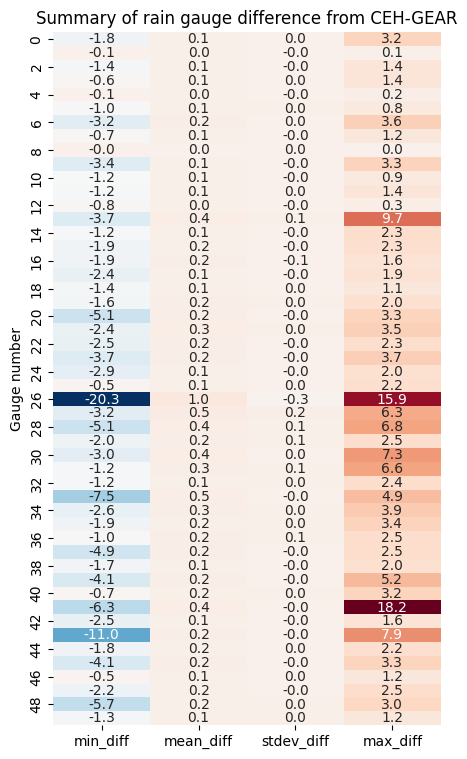

In [68]:
cols_to_plot = ["min_diff", "mean_diff", "stdev_diff", "max_diff"]
fig, ax = plt.subplots(1, figsize=(5, 9))
sns.heatmap(
    all_gauge_comparisons_df.select(cols_to_plot),
    cmap="RdBu_r",
    ax=ax,
    annot=True,
    fmt=".1f",
    cbar=False,
)
ax.set_xticklabels(cols_to_plot)
ax.set_ylabel("Gauge number")
ax.set_title("Summary of rain gauge difference from CEH-GEAR")

Of course, mean and standard deviation are relatively simple summary statistics, but you can imagine we can run more advanced statistics just as easily in this structure.

#### 🤨 Optional task: How correlated are each of the rain gauges to their nearest CEH-GEAR grid cell?
If you cannot immediately think of how to do this, please move on


In [101]:
%%time
# Store correlations in a dictionary
all_gauge_correlations = {}

for gauge_id in all_unique_gauge_ids:
    one_gauge_rainfall_diff = calc_mean_diff_between_rain_gauge_and_nearest_grid_cell(
        gauge_id=gauge_id
    )
    all_gauge_correlations[gauge_id] = one_gauge_rainfall_diff.select(pl.corr("PRECIPITATION_GAUGE", "PRECIPITATION_GRID").alias('gauge_grid_corr'))

CPU times: user 289 ms, sys: 22.9 ms, total: 312 ms
Wall time: 270 ms


In [102]:
all_gauge_correlations

{90358: shape: (1, 1)
 ┌─────────────────┐
 │ gauge_grid_corr │
 │ ---             │
 │ f64             │
 ╞═════════════════╡
 │ 0.999567        │
 └─────────────────┘,
 90803: shape: (1, 1)
 ┌─────────────────┐
 │ gauge_grid_corr │
 │ ---             │
 │ f64             │
 ╞═════════════════╡
 │ 0.999979        │
 └─────────────────┘,
 90805: shape: (1, 1)
 ┌─────────────────┐
 │ gauge_grid_corr │
 │ ---             │
 │ f64             │
 ╞═════════════════╡
 │ 0.999745        │
 └─────────────────┘,
 91177: shape: (1, 1)
 ┌─────────────────┐
 │ gauge_grid_corr │
 │ ---             │
 │ f64             │
 ╞═════════════════╡
 │ 0.999903        │
 └─────────────────┘,
 91196: shape: (1, 1)
 ┌─────────────────┐
 │ gauge_grid_corr │
 │ ---             │
 │ f64             │
 ╞═════════════════╡
 │ 0.999986        │
 └─────────────────┘,
 91773: shape: (1, 1)
 ┌─────────────────┐
 │ gauge_grid_corr │
 │ ---             │
 │ f64             │
 ╞═════════════════╡
 │ 0.999307        │
 └

Moving on, Let's join this data back to the metadata so we can plot the gauges on a map

In [103]:
severn_rain_gauge_metadata_w_comparison = severn_rain_gauge_metadata.join(
    all_gauge_comparisons_df, left_on="ID", right_on="gauge_id"
)

In [104]:
severn_rain_gauge_metadata_w_comparison.head()

ID,SRC_ID,NAME,COUNTRY_CODE,EASTING,NORTHING,HYDROMETRIC_AREA,ELEVATION,GEOG_PATH,stdev_diff,mean_diff,max_diff,min_diff
i64,i64,str,str,i64,i64,i64,i64,str,f64,f64,f64,f64
90358,2918,"""SUGNALL HALL""","""GB-GBN""",379831,331185,28,143,"""/BI/UK/GB/ENG/STS/""",0.005295,0.128633,3.2,-1.834428
90803,625,"""STONE NO 2""","""GB-GBN""",387800,332100,28,107,"""/BI/UK/GB/ENG/STS/""",-0.000049,0.021958,0.120769,-0.129023
90805,56180,"""STONE, COLD NORTON FARM""","""GB-GBN""",387760,332060,28,108,"""/BI/UK/GB/ENG/STS/""",-0.002276,0.090645,1.40221,-1.379021
91177,25321,"""TETTENHALL""","""GB-GBN""",387279,301113,28,122,"""/BI/UK/GB/ENG/WMID/""",0.008214,0.069428,1.370693,-0.613162
91196,2931,"""CODSALL""","""GB-GBN""",387000,302800,28,125,"""/BI/UK/GB/ENG/STS/""",-0.002858,0.019391,0.187988,-0.130631


<Axes: xlabel='Easting', ylabel='Northing'>

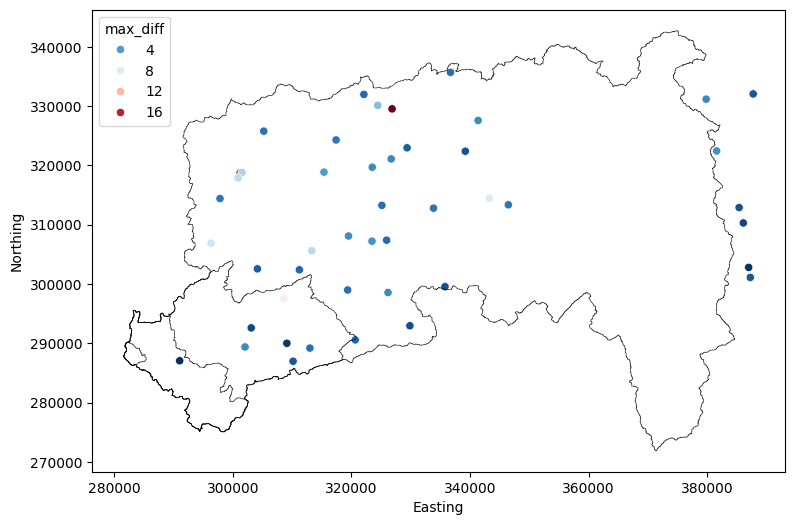

In [105]:
fig, ax = plt.subplots(1, figsize=(12, 6), sharex=True, sharey=True)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
sns.scatterplot(
    x="EASTING",
    y="NORTHING",
    hue="max_diff",
    palette='RdBu_r',
    data=severn_rain_gauge_metadata_w_comparison,
    ax=ax,
)
abermule_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
bewdley_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
dolwen_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
plynlimon_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)

Hmm, there is not a clear spatial pattern in the difference between gauge and gridded data

## 3.3. Comparing catchment-mean rainfall
In this final example, we will compute catchment average rainfall for the smaller catchments in the Upper Severn. We will then examine the differences between the rainfall estimates from the gridded dataset and rain gauge observations.

First, we need to make a mask of the smaller catchments. To do this, we have prepared a small function `make_region_hght_clip` that can clip the topography data, we can then use that to mask CEH-GEAR rainfall data.

In [106]:
# Make region clips using the Upper Severn catchment shapefiles
abermule_hght = data_utils.make_region_hght_clip(abermule_shp, hght_data=severn_hght)
dolwen_hght = data_utils.make_region_hght_clip(dolwen_shp, hght_data=severn_hght)
plynlimon_hght = data_utils.make_region_hght_clip(plynlimon_shp, hght_data=severn_hght)

Don't worry about understanding the code, but basically we can show what this is doing in the next plot...

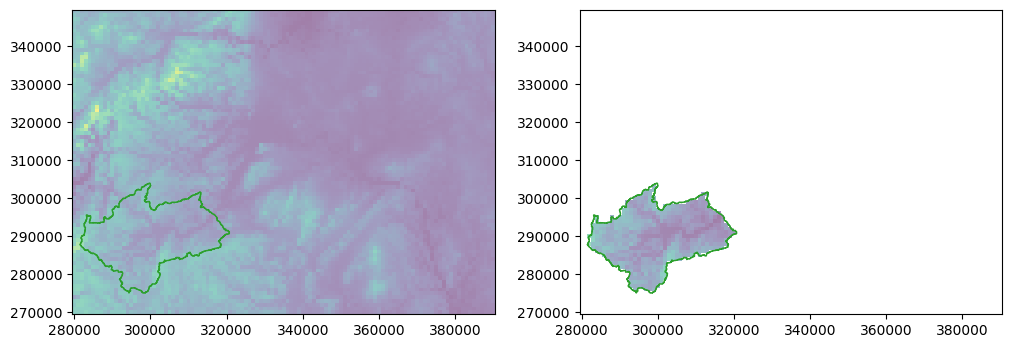

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
severn_hght.plot(ax=axes[0], vmax=880, alpha=0.5, add_colorbar=False)
abermule_hght.plot(ax=axes[1], vmax=880, alpha=0.5, add_colorbar=False)

for ax in axes:
    abermule_shp.plot(ax=ax, facecolor="none", edgecolor="C2")
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")

Next, we can mask the CEH-GEAR rainfall data to each region using another function `mask_regional_rainfall` which will create a subset based on the masks we just created. Again do not worry about the specifics, but if interested please look in the `data_utils.py` function. On a side note, it is always a good idea to move heavier functions outside of the notebook to keep things clean

In [108]:
%%time
# Takes 60 seconds
abermule_mask_rainfall = data_utils.mask_region_rainfall(
    severn_gear_daily, abermule_hght
)
dolwen_mask_rainfall = data_utils.mask_region_rainfall(severn_gear_daily, dolwen_hght)
plynlimon_mask_rainfall = data_utils.mask_region_rainfall(
    severn_gear_daily, plynlimon_hght
)

CPU times: user 222 ms, sys: 373 ms, total: 595 ms
Wall time: 597 ms


Let's plot this, so we can see what it has done

In [109]:
date_to_examine = "2018-01-01"  # feel free to look at other dates

Text(0.5, 1.0, 'Rainfall in Abermule catchment')

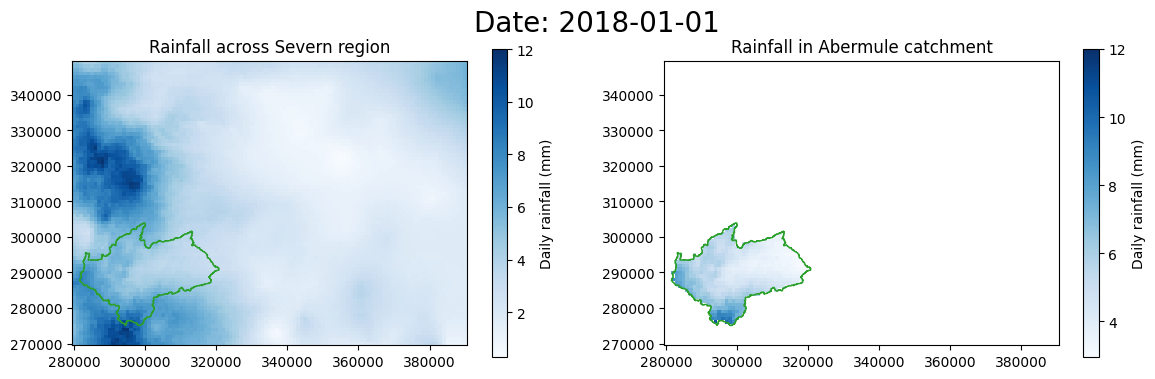

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
severn_gear_daily.sel(time=date_to_examine)["rainfall_amount"].plot(
    ax=axes[0], vmax=12, cmap="Blues", cbar_kwargs={"label": "Daily rainfall (mm)"}
)

abermule_mask_rainfall.sel(time=date_to_examine)["rainfall_amount"].plot(
    ax=axes[1], vmax=12, cmap="Blues", cbar_kwargs={"label": "Daily rainfall (mm)"}
)

for ax in axes:
    abermule_shp.plot(ax=ax, facecolor="none", edgecolor="C2")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle(f"Date: {date_to_examine}", size=20)
axes[0].set_title("Rainfall across Severn region")
axes[1].set_title("Rainfall in Abermule catchment")

### 3.3.1 Calculate the 1990-2019 mean catchment and compare rainfall estimates across the 3 Upper Severn catchments
Okay, we have the masks, now let's compute a 1990-2010 mean rainfall to see which parts of the catchment are wettest on average.

In [111]:
catchments_shp_and_hght = {
    "Abermule": {"shp": abermule_shp, "hght": abermule_hght},
    "Dolwen": {"shp": dolwen_shp, "hght": dolwen_hght},
    "Plynlimon Flume": {"shp": plynlimon_shp, "hght": plynlimon_hght},
}

In [112]:
%%time
abermule_rain = data_utils.mask_region_rainfall(
    severn_gear_daily, catchments_shp_and_hght["Abermule"]["hght"]
)

CPU times: user 69.7 ms, sys: 131 ms, total: 201 ms
Wall time: 201 ms


To compute the spatial mean, we need to run `.mean("time")`, so it will take a mean of the time coordinates (leaving only x, y)

In [113]:
%%time
abermule_mean_rain = abermule_rain.mean("time")["rainfall_amount"]

CPU times: user 219 ms, sys: 1.76 ms, total: 221 ms
Wall time: 222 ms


(270000.0, 310000.0)

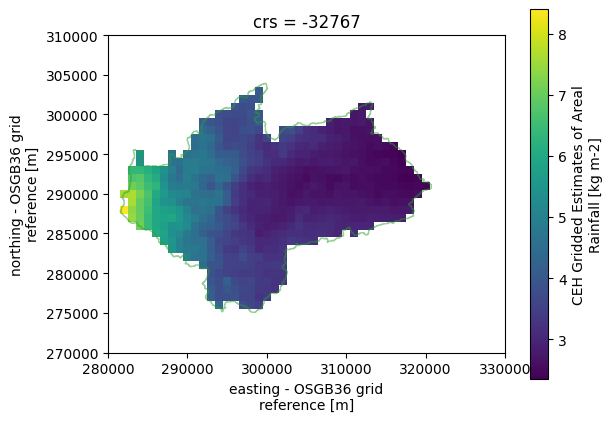

In [114]:
fig, ax = plt.subplots(1)

abermule_mean_rain.plot(ax=ax)
catchments_shp_and_hght["Abermule"]["shp"].plot(
    ax=ax, facecolor="none", edgecolor='C2', alpha=0.5
)
ax.set_xlim(280000, 330000)
ax.set_ylim(270000, 310000)

We loop through each of the catchments and plot them next

CPU times: user 1.45 s, sys: 457 ms, total: 1.91 s
Wall time: 1.92 s


(270000.0, 310000.0)

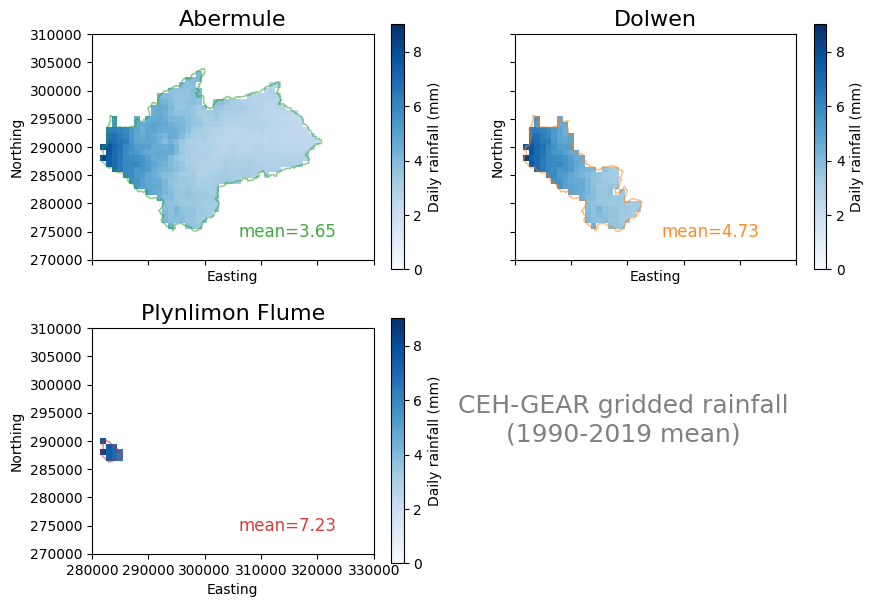

In [115]:
%%time
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

for ax, catchment, color_to_use in zip(
    axes.flatten(), catchments_shp_and_hght.keys(), ["C2", "C1", "C3"]
):
    region_mask_rain = data_utils.mask_region_rainfall(
        severn_gear_daily, catchments_shp_and_hght[catchment]["hght"]
    ).mean("time")["rainfall_amount"]
    region_mask_rain.plot(
        ax=ax,
        vmin=0,
        vmax=9,
        cmap="Blues",
        cbar_kwargs={"label": "Daily rainfall (mm)"},
    )
    catchments_shp_and_hght[catchment]["shp"].plot(
        ax=ax, facecolor="none", edgecolor=color_to_use, alpha=0.5
    )
    ax.set_title(f"{catchment}", size=16)
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")
    ax.text(
        s=f"mean={region_mask_rain.mean():.2f}",
        x=306000,
        y=274000,
        size=12,
        color=color_to_use,
        alpha=0.9,
    )
axes[1][1].remove()
axes[1][0].text(
    s="CEH-GEAR gridded rainfall\n      (1990-2019 mean)",
    x=345000,
    y=290000,
    size=18,
    color="grey",
)
ax.set_xlim(280000, 330000)
ax.set_ylim(270000, 310000)

I wonder if the height profile has anything to do with spatial pattern of the mean rainfall?

### 3.3.2 Comparing catchment rainfall estimates through time
In 3.3.1, we look at the spatial catchment average, how about the time-average of the catchment rainfall

In [116]:
# to keep RAM-use low, let's take a subset of data from 2010-2019
abermule_mask_rainfall_2010s = abermule_mask_rainfall.sel(time=slice("2010", "2019"))

To compute the time mean, we need to run `.mean(("x", "y"))`, so it will take a mean of the x, y coordinates (leaving only time)

In [117]:
%%time
abermule_catchment_mean_rainfall_2010s = abermule_mask_rainfall_2010s[
    "rainfall_amount"
].mean(("x", "y"))

CPU times: user 88.3 ms, sys: 35.2 ms, total: 123 ms
Wall time: 123 ms


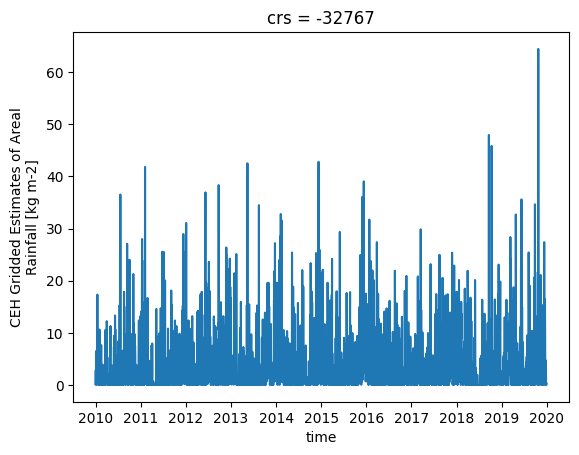

In [118]:
abermule_catchment_mean_rainfall_2010s.plot()

Okay, what about the rain gauges within those catchments, what do they estimate?  
Next, we will compare the catchment average of the CEH-GEAR to the average of the rain gauges in the catchment. For this purpose, we will convert the metadata into a geodataframe. This will allow us to compute a [Point in Polygon](https://en.wikipedia.org/wiki/Point_in_polygon) operation, where the 'points' are the rain gauge location, and the 'polygons' are the catchment boundaries i.e. `abermule_shp`

In [119]:
# Create a geometry column for the metadata gdf based on the X,Y coordiantes of rain gauges
geometry = [
    shapely.geometry.Point(xy)
    for xy in zip(
        severn_rain_gauge_metadata_w_comparison["EASTING"],
        severn_rain_gauge_metadata_w_comparison["NORTHING"],
    )
]

In [120]:
# Create a GeoDataFrame using that geometry
severn_rain_gauge_metadata_gdf = gpd.GeoDataFrame(
    severn_rain_gauge_metadata_w_comparison.to_pandas(),
    geometry=geometry,
    crs="EPSG:27700",
)

In [121]:
severn_rain_gauge_metadata_gdf.head()

,ID,SRC_ID,NAME,COUNTRY_CODE,EASTING,NORTHING,HYDROMETRIC_AREA,ELEVATION,GEOG_PATH,stdev_diff,mean_diff,max_diff,min_diff,geometry
0,90358,2918,SUGNALL HALL,GB-GBN,379831,331185,28,143,/BI/UK/GB/ENG/STS/,0.005295,0.128633,3.200000,-1.834428,POINT (379831 331185)
1,90803,625,STONE NO 2,GB-GBN,387800,332100,28,107,/BI/UK/GB/ENG/STS/,-0.000049,0.021958,0.120769,-0.129023,POINT (387800 332100)
2,90805,56180,"STONE, COLD NORTON FARM",GB-GBN,387760,332060,28,108,/BI/UK/GB/ENG/STS/,-0.002276,0.090645,1.402210,-1.379021,POINT (387760 332060)
3,91177,25321,TETTENHALL,GB-GBN,387279,301113,28,122,/BI/UK/GB/ENG/WMID/,0.008214,0.069428,1.370693,-0.613162,POINT (387279 301113)
4,91196,2931,CODSALL,GB-GBN,387000,302800,28,125,/BI/UK/GB/ENG/STS/,-0.002858,0.019391,0.187988,-0.130631,POINT (387000 302800)


##### ❓ Question: What data type is `severn_rain_gauge_metadata_gdf`?
**Answer:** ???

Let's look at the data we just created using a web map

In [122]:
severn_rain_gauge_metadata_gdf.explore()

Below we use a `.contains()` method to compute Point in Polygon operation i.e. is a given rain gauge within the abermule shapefile

In [123]:
abermule_metadata = severn_rain_gauge_metadata_gdf.loc[
    severn_rain_gauge_metadata_gdf.apply(
        lambda row: abermule_shp.contains(row["geometry"]), axis=1
    ).values
]

Let's view the gauges within one of the Upper Severn catchments: Abermule

<Axes: >

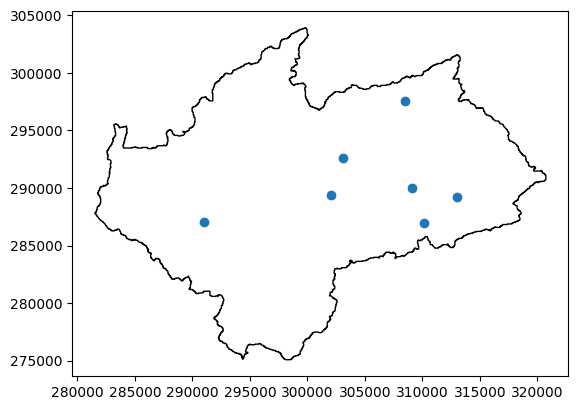

In [124]:
fig, ax = plt.subplots(1)
abermule_metadata.plot(ax=ax)
abermule_shp.plot(ax=ax, facecolor="none")

Let's get the rain gauge data for those Abermule gauge IDs

In [125]:
abermule_rain_gauge_data = severn_rain_gauge_data_filtered.filter(
    pl.col("ID").is_in(abermule_metadata["ID"].to_list())
)

In the next step, we pivot the Abermule rain gauge data so that each column refers to a different gauge. Rather than describing how this works, have a look at the output data

In [126]:
abermule_rain_gauge_data_pivot = abermule_rain_gauge_data.pivot(
    on="ID", index="DATETIME", values="PRECIPITATION"
)

# Sort the pivot table by time (for plotting purporses)
abermule_rain_gauge_data_pivot = abermule_rain_gauge_data_pivot.sort(by="DATETIME")

In [127]:
abermule_rain_gauge_data_pivot.head()

DATETIME,421234,421484,422091,422328,422367,422493,422693
datetime[μs],f64,f64,f64,f64,f64,f64,f64
1990-01-02 00:00:00,6.2,3.7,null,4.5,4.7,5.0,4.8
1990-01-03 00:00:00,0.1,0.0,null,0.0,0.1,0.1,0.0
1990-01-04 00:00:00,0.0,0.0,null,0.0,0.0,0.0,0.0
1990-01-05 00:00:00,5.2,7.1,null,4.5,4.3,5.6,5.2
1990-01-06 00:00:00,1.4,0.6,null,2.1,1.3,2.4,3.0


We will quickly visualise the 6 month rolling mean for these Abermule rain gauges. Don't worry about the code below

In [128]:
abermule_rain_gauge_data_6month = abermule_rain_gauge_data_pivot.group_by_dynamic(
    "DATETIME", every="6mo"
).agg([pl.col(col).mean() for col in abermule_rain_gauge_data_pivot.columns[1:]])

<Axes: xlabel='DATETIME'>

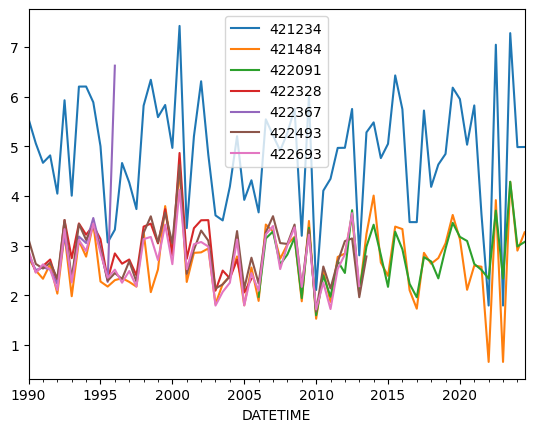

In [129]:
abermule_rain_gauge_data_6month.to_pandas().set_index("DATETIME").plot()

Finally, we will get data from 2010-2019

In [130]:
abermule_rain_gauge_data_2010s = abermule_rain_gauge_data_pivot.filter(
    (pl.col("DATETIME") >= pl.datetime(year=2010, month=1, day=1))
    & (pl.col("DATETIME") < pl.datetime(year=2019, month=12, day=31))
)

And compute a mean of all the gauges in the Abermule catchment

In [131]:
abermule_rain_gauge_data_2010s = abermule_rain_gauge_data_2010s.with_columns(
    pl.mean_horizontal(pl.all().exclude("DATETIME")).alias("gauge mean")
)

In [132]:
abermule_rain_gauge_data_2010s

DATETIME,421234,421484,422091,422328,422367,422493,422693,gauge mean
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2010-01-01 00:00:00,0.3,0.0,0.0,null,null,0.0,0.1,0.08
2010-01-02 00:00:00,1.8,1.5,2.6,null,null,1.5,3.0,2.08
2010-01-03 00:00:00,0.0,0.0,0.0,null,null,0.0,0.0,0.0
2010-01-04 00:00:00,5.6,2.5,0.0,null,null,0.0,0.1,1.64
2010-01-05 00:00:00,10.6,6.9,3.2,null,null,6.4,3.1,6.04
…,…,…,…,…,…,…,…,…
2019-12-26 00:00:00,4.8,2.4,null,null,null,null,null,3.6
2019-12-27 00:00:00,0.1,0.0,null,null,null,null,null,0.05
2019-12-28 00:00:00,0.0,0.0,null,null,null,null,null,0.0


In [133]:
abermule_rain_gauge_data_2010s["gauge mean"].plot.line()

alt.Chart(...)

Here's the catchment-wide mean from CEH-GEAR again:

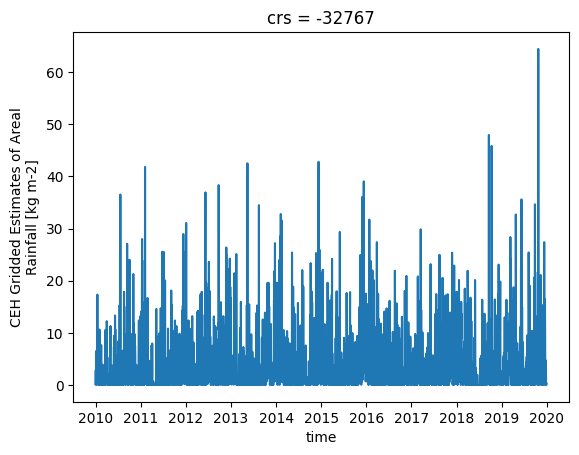

In [134]:
abermule_mask_rainfall_2010s['rainfall_amount'].mean(('x', 'y')).plot()

hmm, they look similar, but are they? See additional task 1 if you would like to continue

In [135]:
abermule_rain_gauge_data_2010s['gauge mean'].mean()

3.302317173377157

In [136]:
abermule_mask_rainfall_2010s['rainfall_amount'].mean()

<xarray.DataArray 'rainfall_amount' ()> Size: 8B
array(3.54204639)
Coordinates:
    crs      int16 2B -32767
Attributes:
    comment:        The estimated rainfall amount (kg m-2) is equivalent to t...
    long_name:      CEH Gridded Estimates of Areal Rainfall
    standard_name:  rainfall_amount
    units:          kg m-2
    valid_max:      10000.0
    valid_min:      -20.0

### 3.3.3 Plot catchment mean rainfall comparison

Let's first get the mean rainfall for each rain gauge in the Abermule sub-catchment

In [137]:
abermule_rain_gauge_data_2010s_means = abermule_rain_gauge_data_2010s.mean().drop(['DATETIME', 'gauge mean']).unpivot(
        variable_name="ID",
        value_name="mean_rainfall"
).with_columns(pl.col("ID").cast(pl.Int64))

In [138]:
abermule_metadata_w_mean_rainfall = abermule_metadata.merge(
    abermule_rain_gauge_data_2010s_means.to_pandas(), on="ID"
)

In [139]:
abermule_metadata_w_mean_rainfall

,ID,SRC_ID,NAME,COUNTRY_CODE,EASTING,NORTHING,HYDROMETRIC_AREA,ELEVATION,GEOG_PATH,stdev_diff,mean_diff,max_diff,min_diff,geometry,mean_rainfall
0,421234,16800,CLYWEDOG DAM,GB-GBN,291018,287054,54,290,/BI/UK/GB/WAL/POWN/,9.301813e-19,4.409192e-16,7.105427e-15,-1.421085e-14,POINT (291018 287054),4.732481
1,421484,9674,LLANDINAM,GB-GBN,302044,289380,54,135,/BI/UK/GB/WAL/POWN/,-1.148241e-03,1.391712e-01,3.333037e+00,-3.383162e+00,POINT (302044 289380),2.752072
2,422091,55924,HENFRYN,GB-GBN,303086,292597,54,130,/BI/UK/GB/WAL/POWS/,-2.744941e-02,9.843975e-02,8.661125e-01,-1.155718e+00,POINT (303086 292597),2.636006
3,422328,9686,DOLFOR,GB-GBN,310149,286973,54,312,/BI/UK/GB/WAL/POWN/,1.197235e-02,1.261500e-01,1.409867e+00,-1.226077e+00,POINT (310149 286973),NaN
4,422367,1192,NEWTOWN,GB-GBN,309100,290000,54,120,/BI/UK/GB/WAL/POWN/,-2.424361e-03,2.574136e-02,3.457944e-01,-8.066429e-01,POINT (309100 290000),NaN
5,422493,9689,GREGYNOG HALL NO 2,GB-GBN,308522,297540,54,192,/BI/UK/GB/WAL/POWN/,1.323121e-01,3.850887e-01,9.664929e+00,-3.707063e+00,POINT (308522 297540),2.511147
6,422693,9691,LOWER CEFN PERFA,GB-GBN,312987,289188,54,229,/BI/UK/GB/WAL/POWN/,-3.570798e-03,6.340670e-02,2.338548e+00,-1.230910e+00,POINT (312987 289188),2.413469


In [140]:
abermule_rain_gauge_data_2010s.mean()['gauge mean']

gauge mean
f64
3.302317


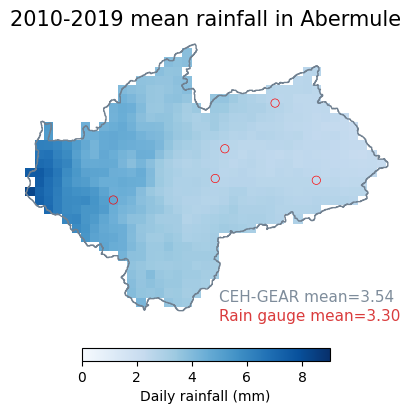

In [141]:
fig, ax = plt.subplots(1)
abermule_mask_rainfall_2010s = abermule_mask_rainfall.sel(time=slice("2010", "2019"))
abermule_mask_rainfall_2010s = abermule_mask_rainfall_2010s.mean("time")["rainfall_amount"]
abermule_mask_rainfall_2010s.plot(
    ax=ax,
    vmin=0,
    vmax=9,
    cmap="Blues",
    cbar_kwargs={"label": "Daily rainfall (mm)", 'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.05},
)
abermule_shp.plot(ax=ax, facecolor='none', edgecolor='slategrey')
sns.scatterplot(
    x="EASTING",
    y="NORTHING",
    hue="mean_rainfall",
    palette='Blues',
    data=abermule_metadata_w_mean_rainfall,
    legend=False,
    ax=ax,
    hue_norm=(0, 9),
    edgecolor='r',
)

ax.text(
    s=f"CEH-GEAR mean={abermule_mask_rainfall_2010s.mean():.2f}",
    x=302500,
    y=276000,
    size=11,
    color='slategrey',
    alpha=0.9,
)
ax.text(
    s=f"Rain gauge mean={abermule_rain_gauge_data_2010s.mean()['gauge mean'][0]:.2f}",
    x=302500,
    y=274000,
    size=11,
    color='C3',
    alpha=0.9,
)
ax.set_ylim(273000, 305000)
ax.set_xlim(280000, 322000)
ax.axis('off')
ax.set_title("2010-2019 mean rainfall in Abermule", size=15);
# fig.savefig("content/example_abermule_mean_rainfall.png", bbox_inches='tight')

# 4. Saving research outputs
Finally, it is essential when doing any research to save your outputs. Especially when the outputs take a while to load, and compute.   
Because we have read `.csv` files with polars, we can use polars to save `.csv` files.  
Because we have read `.nc` (NetCDF) files with xarray, we can use polars to save `.nc` files.  

We'll give you some examples below...

#### 🤨 Optional task: Save research outputs to appropriate file system (and to use later)
Replace the `???` with the path to where you want to save your data, please ask for help if needed

*NOTE: you might save these things under different names*


In [142]:
abermule_rain_gauge_data_2010s.write_csv(f"abermule_rain_gauge_data_2010s.csv")

In [144]:
abermule_catchment_mean_rainfall_2010s.to_netcdf(f"abermule_catchment_mean_rainfall_2010s.nc")

# 5. Additional tasks ❗❗  

Feel free to stop at this point, but below are some additional and more advanced topics and tasks requiring more of your own input. We will provide help.  

Select any of the following:

*Task 1. Compare catchment-wide rainfall estimates (gridded rainfall vs rain gauge)* 🟢  
*Task 2. A case study of an unseen rain gauge in the Upper Severn* 🟡  
*Task 3. Does rainfall disproportionately fall at higher altitudes before floods in the Upper Severn?* 🔴  

#### Task Difficulty:
- 🟢 -> easy, you should have all of the code to do this
- 🟡 -> moderate, will require a little more work and a better understanding of the data
- 🔴 -> hard, requires lots of independent thought


## ⭐ Please do any work for the additional tasks in a new notebook, save any useful research outputs ⭐


## 🟢 Additonal Task 1: Compare catchment-wide rainfall estimates (gridded rainfall vs rain gauge)
> Note: please do this in a new notebook file

We already should have catchment-mean rainfall for the Abermule catchment loaded in (in section 3.3.2), so you choose to do this task just below. It may be a good learning opportunity to develop your own statistical analysis. Perhaps by running a linear regression?

*Hint: you could import the `scipy.stats` library to run statistics and `numpy` gives you access to regression*  
*Hint: Consider using (monthly) running means to plot data*  

<p float="left">
    <img src="https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/update/workshop-4/Workshop_4/content/example_abermule_mean_rainfall.png" alt="abermule-rain-mean" style="width:400px;"/>
</p>

*Figure 4. Example of catchment-mean rainfall for the Abermule sub-catchment in the Severn.*

In [ ]:
abermule_catchment_mean_rainfall_2010s

In [ ]:
abermule_rain_gauge_data_2010s

## 🟡 Additional Task 2. Case Study: A case study of an unseen rain gauge in the Upper Severn
> Note: please do this in a new notebook file

The CEH-GEAR gridded product was produced on the rain gauge data we have used in this practical. As such, there is a direct spill of information between them. On the JASMIN object store there is an additional "unseen" rain gauge near Carreg Wen within the Plynlimon catchment that wasn't included in the original CEH-GEAR methdology. It exists in a blind spot.

#### Some research questions:
- How closely do the CEH grid cells around Carreg Wen estimate rainfall?
- Has the gridded product under or over-estimated rainfall in the days before a flood?

*Hint: If you really need a hint, you can check this [notebook](https://github.com/NERC-CEH/FDRI-comparing-rainfall-data-in-upper-severn/blob/main/notebooks/Carreg_wen_case_study.ipynb)*

In [ ]:
carreg_wen_daily = pl.read_csv(
    "s3://rain-gauge/carreg_wen_daily_rainfall.csv",
    storage_options={"endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk", "anon": True},
    try_parse_dates=True,
)
carreg_wen_daily.head()

In [ ]:
severn_rain_gauge_metadata.filter(pl.col("NAME") == "CARREG WEN")

In [ ]:
fig, ax = plt.subplots(1)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
abermule_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
bewdley_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
dolwen_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
plynlimon_shp.plot(ax=ax, facecolor="none", alpha=0.8, linewidth=0.5)
sns.scatterplot(
    x="EASTING",
    y="NORTHING",
    data=severn_rain_gauge_metadata.filter(pl.col("ID").is_in(reliable_gauge_ids)),
)

ax.scatter(severn_rain_gauge_metadata.filter(pl.col("NAME") == "CARREG WEN")['EASTING'], severn_rain_gauge_metadata.filter(pl.col("NAME") == "CARREG WEN")['NORTHING'])
ax.legend(['Rain Gauges in CEH-GEAR', 'Carreg Wen'])
ax.set_title("Distribution of rain gauges in Upper Severn")
# fig.savefig('content/distribution_of_rain_gauges.png', bbox_inches='tight')

## 🔴 Additional Task 3. Does rainfall disproportionately fall at higher altitudes during floods in the Upper Severn?
> Note: please do this in a new notebook file

If you need a hint, check out some of the plots and notebooks in: https://github.com/NERC-CEH/FDRI-high-altitude-rainfall-and-floods


<p float="left">
    <img src="https://raw.githubusercontent.com/NERC-CEH/FDRI-high-altitude-rainfall-and-floods/refs/heads/main/River Severn/Figures/fiveflood_mean_bewdley_10d_prop_rain.png" alt="flood" style="width:600px;"/>
</p>

*Figure 6. Proportion of rainfall above different heights during 5-flood events in the Upper Severn.*

In [ ]:
# The heaviest rainfall is often a day or two before the flood event
EXAMPLE_FLOOD_DAYS_IN_SEVERN = [
    "1984-11-13",
    "1986-12-16",
    "1986-12-19",
    "1988-03-16",
    "1988-03-20",
    "1990-03-01",
    "1990-12-27",
    "1994-01-04",
    "1994-01-14",
    "1994-02-28",
    "1994-04-05",
    "1994-04-10",
    "1995-01-22",
    "1995-12-24",
    "1996-02-13",
    "2000-09-28",
    "2001-02-13",
    "2002-01-28",
    "2002-11-15",
    "2007-01-01",
    "2008-03-17",
    "2008-11-11",
    "2012-04-30",
    "2013-02-15",
    "2020-01-15",
]

In [ ]:
# A function for masking rainfall data by height
def mask_region_rainfall_by_hght(rainfall_data, region_hght, threshold):
    region_hght_mask = region_hght / region_hght.where(region_hght > threshold)
    return rainfall_data * region_hght_mask.data

# Additional Reading

- <https://github.com/NERC-CEH/FDRI-comparing-rainfall-data-in-upper-severn/tree/main>  

- <https://github.com/NERC-CEH/FDRI-high-altitude-rainfall-and-floods>